# Autoencoders with Fashion MNIST

This notebook explores various types of autoencoders using the Fashion MNIST dataset. Autoencoders are neural networks that learn an efficient encoding of input data, typically for dimensionality reduction or feature learning. We will implement and visualize the performance of:

*   **Stacked Autoencoders**
*   **Autoencoders Trained One-at-a-Time**
*   **Convolutional Autoencoders**
*   **Recurrent Autoencoders**
*   **Denoising Autoencoders (with Gaussian Noise and Dropout)**
*   **Sparse Autoencoders (with KL Divergence Regularization)**

Each section will include the model definition, training, and visualization of reconstructed images or latent space representations.

In [ ]:
import sklearn
assert sklearn.__version__ >= "0.20"
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

### Setup and Data Loading

First, we import the necessary libraries and load the Fashion MNIST dataset. The images are preprocessed by scaling them to the range [0, 1] and splitting them into training, validation, and test sets.

In [ ]:
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

### Stacked Autoencoders with Fashion MNIST

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


The Fashion MNIST dataset is loaded and normalized. We split the training data to create a validation set for monitoring model performance during training.

In [ ]:
def rounded_accuracy(y_true, y_pred):
    return keras.metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

We define a custom metric, `rounded_accuracy`, to evaluate the autoencoders. Since the output layer uses a sigmoid activation, the output values are probabilities, and rounding them to 0 or 1 allows for a binary accuracy calculation.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

stacked_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu"),
])
stacked_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[30]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])
stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])
stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=keras.optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy])
history = stacked_ae.fit(X_train, X_train, epochs=25,
                         validation_data=(X_valid, X_valid))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3375 - rounded_accuracy: 0.8873 - val_loss: 0.3192 - val_rounded_accuracy: 0.8955
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3056 - rounded_accuracy: 0.9151 - val_loss: 0.3092 - val_rounded_accuracy: 0.9050
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2991 - rounded_accuracy: 0.9210 - val_loss: 0.3027 - val_rounded_accuracy: 0.9127
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2953 - rounded_accuracy: 0.9243 - val_loss: 0.2978 - val_rounded_accuracy: 0.9192
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2925 - rounded_accuracy: 0.9267 - val_loss: 0.2947 - val_rounded_accuracy: 0.9222
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2904 - rounded_accuracy: 0.9285 - val_loss: 0.2942 - val_rounded_accuracy: 0.9211
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2887 - rounded_accuracy: 0.9303 - val_loss: 0.2920 - val_rou

### Stacked Autoencoder

A stacked autoencoder consists of multiple dense layers. The encoder part maps the input to a lower-dimensional latent space, and the decoder reconstructs the input from this latent representation. Both encoder and decoder are trained simultaneously.

In [ ]:
def show_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


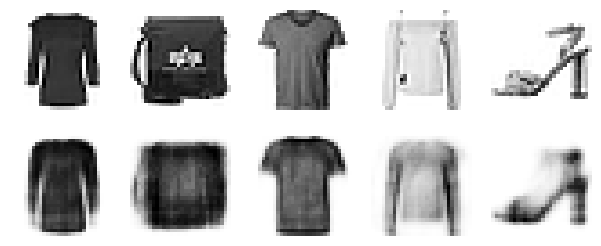

In [ ]:
show_reconstructions(stacked_ae)

The `show_reconstructions` function visualizes the original images (top row) and their corresponding reconstructions by the autoencoder (bottom row). This helps to qualitatively assess how well the autoencoder can compress and reconstruct the data.

In [ ]:
from sklearn.manifold import TSNE

X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE()
X_valid_2D = tsne.fit_transform(X_valid_compressed)
X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### Latent Space Visualization with t-SNE

To understand how the autoencoder organizes the data in its latent space, we use t-Distributed Stochastic Neighbor Embedding (t-SNE). t-SNE is a dimensionality reduction technique well-suited for visualizing high-dimensional data in a 2D or 3D space, preserving local structures. Here, we visualize the compressed representation (codings) of the validation set.

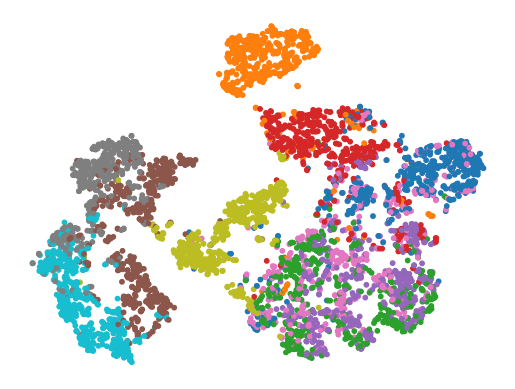

In [ ]:
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.axis("off")
plt.show()

This t-SNE plot shows the 2D representation of the encoded validation images. Each point represents an image, colored by its class. Ideally, images from the same class should cluster together, indicating that the encoder has learned meaningful features.

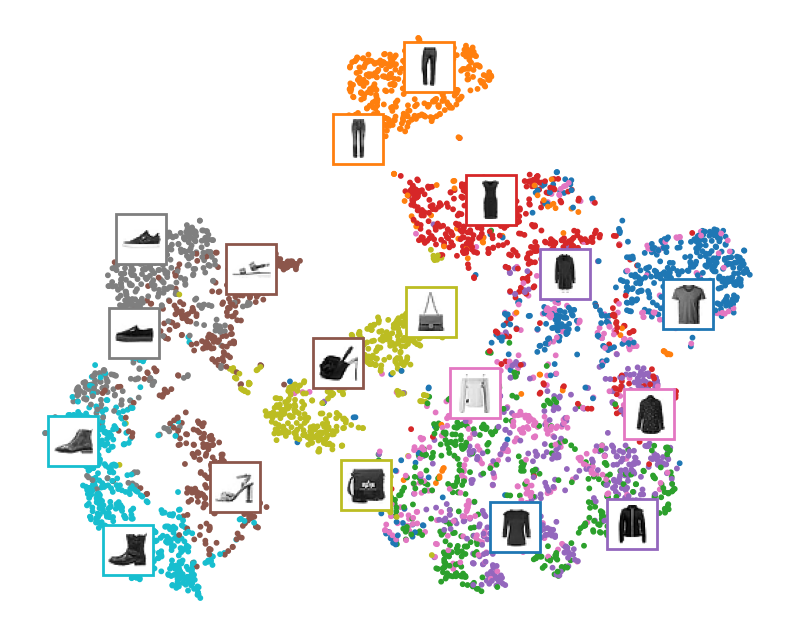

In [ ]:
# adapted from https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(X_valid_2D):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index], cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)
plt.axis("off")
plt.show()

This advanced t-SNE visualization overlays actual image patches onto their corresponding positions in the 2D latent space. This provides a clearer understanding of which types of images are grouped together by the autoencoder and how distinct classes are separated.

###training one Autoencoder at a time

### Training Autoencoders One-at-a-Time

Instead of training the entire stacked autoencoder at once, we can train each autoencoder layer individually. The output of one encoder becomes the input for the next, providing a greedy layer-wise training approach. This can sometimes lead to better feature extraction.

In [ ]:
def train_autoencoder(n_neurons, X_train, X_valid, loss, optimizer,
                      n_epochs=10, output_activation=None, metrics=None):
    n_inputs = X_train.shape[-1]
    encoder = keras.models.Sequential([
        keras.layers.Dense(n_neurons, activation="selu", input_shape=[n_inputs])
    ])
    decoder = keras.models.Sequential([
        keras.layers.Dense(n_inputs, activation=output_activation),
    ])
    autoencoder = keras.models.Sequential([encoder, decoder])
    autoencoder.compile(optimizer, loss, metrics=metrics)
    autoencoder.fit(X_train, X_train, epochs=n_epochs,
                    validation_data=(X_valid, X_valid))
    return encoder, decoder, encoder(X_train), encoder(X_valid)

The `train_autoencoder` function facilitates training individual autoencoder layers. It takes the number of neurons, input data, loss function, optimizer, and other parameters to train a single encoder-decoder pair.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

K = keras.backend
X_train_flat = K.batch_flatten(X_train) # equivalent to .reshape(-1, 28 * 28)
X_valid_flat = K.batch_flatten(X_valid)
enc1, dec1, X_train_enc1, X_valid_enc1 = train_autoencoder(
    100, X_train_flat, X_valid_flat, "binary_crossentropy",
    keras.optimizers.SGD(learning_rate=1.5), output_activation="sigmoid",
    metrics=[rounded_accuracy])
enc2, dec2, _, _ = train_autoencoder(
    30, X_train_enc1, X_valid_enc1, "mse", keras.optimizers.SGD(learning_rate=0.05),
    output_activation="selu")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.3441 - rounded_accuracy: 0.8883 - val_loss: 0.3108 - val_rounded_accuracy: 0.9162
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.3025 - rounded_accuracy: 0.9217 - val_loss: 0.2994 - val_rounded_accuracy: 0.9257
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2939 - rounded_accuracy: 0.9295 - val_loss: 0.2926 - val_rounded_accuracy: 0.9322
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2884 - rounded_accuracy: 0.9349 - val_loss: 0.2882 - val_rounded_accuracy: 0.9365
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2848 - rounded_accuracy: 0.9384 - val_loss: 0.2852 - val_rounded_accuracy: 0.9394
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2822 - rounded_accuracy: 0.9409 - val_loss: 0.2829 - val_rounded_accuracy: 0.9415
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2802 - rounded_accuracy: 0.9428 - val_loss: 0.2812 - val_r

Here, we train two autoencoder layers sequentially. The first layer (`enc1`, `dec1`) reduces the dimensionality to 100, and its encoded output (`X_train_enc1`, `X_valid_enc1`) is then used as input for the second layer (`enc2`, `dec2`), which further reduces it to 30 dimensions. Finally, we combine these pre-trained layers into a full stacked autoencoder.

In [ ]:
stacked_ae_1_by_1 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    enc1, enc2, dec2, dec1,
    keras.layers.Reshape([28, 28])
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


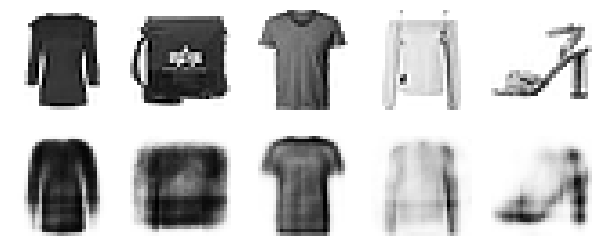

In [ ]:
show_reconstructions(stacked_ae_1_by_1)
plt.show()

Similar to the directly trained stacked autoencoder, we visualize reconstructions from the greedily trained model. Comparing these reconstructions can provide insights into the effectiveness of different training strategies.

### Using convolution layers instead of dense

### Convolutional Autoencoders

For image data, convolutional layers are often more effective than dense layers because they can capture spatial hierarchies and local patterns. A convolutional autoencoder uses convolutional layers in the encoder and deconvolutional (Conv2DTranspose) layers in the decoder.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

conv_encoder = keras.models.Sequential([
    keras.layers.Reshape([28, 28, 1], input_shape=[28, 28]),
    keras.layers.Conv2D(16, kernel_size=3, padding="SAME", activation="selu"),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(32, kernel_size=3, padding="SAME", activation="selu"),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(64, kernel_size=3, padding="SAME", activation="selu"),
    keras.layers.MaxPool2D(pool_size=2)
])
conv_decoder = keras.models.Sequential([
    keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="VALID", activation="selu",
                                 input_shape=[3, 3, 64]),
    keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="SAME", activation="selu"),
    keras.layers.Conv2DTranspose(1, kernel_size=3, strides=2, padding="SAME", activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])
conv_ae = keras.models.Sequential([conv_encoder, conv_decoder])

conv_ae.compile(loss="binary_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=1.0),
                metrics=[rounded_accuracy])
history = conv_ae.fit(X_train, X_train, epochs=5,
                      validation_data=(X_valid, X_valid))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.2995 - rounded_accuracy: 0.9203 - val_loss: 0.2844 - val_rounded_accuracy: 0.9289
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.2750 - rounded_accuracy: 0.9419 - val_loss: 0.2747 - val_rounded_accuracy: 0.9416
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2705 - rounded_accuracy: 0.9465 - val_loss: 0.2702 - val_rounded_accuracy: 0.9473
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2679 - rounded_accuracy: 0.9492 - val_loss: 0.2676 - val_rounded_accuracy: 0.9508
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2662 - rounded_accuracy: 0.9511 - val_loss: 0.2661 - val_rounded_accuracy: 0.9531


This convolutional autoencoder uses `Conv2D` layers with max-pooling for the encoder to progressively reduce the spatial dimensions and extract features. The decoder uses `Conv2DTranspose` (also known as deconvolutional layers) to upsample and reconstruct the image.

In [ ]:
conv_encoder.summary()
conv_decoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,296 (91.00 KB)

 Trainable params: 23,296 (91.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 7, 7, 32)       │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,233 (90.75 KB)

 Trainable params: 23,233 (90.75 KB)

 Non-trainable params: 0 (0.00 B)

The summary provides details of the layers, output shapes, and number of parameters for both the encoder and decoder. This is useful for understanding the architecture.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


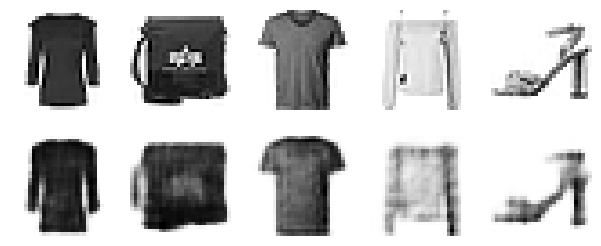

In [ ]:
show_reconstructions(conv_ae)
plt.show()

Visualizing reconstructions from the convolutional autoencoder allows us to see if the model has learned to capture the spatial features of the Fashion MNIST images effectively. Often, convolutional autoencoders produce sharper and more detailed reconstructions than dense autoencoders for image tasks.

### Recurrent Autoencoders

### Recurrent Autoencoders

Recurrent autoencoders are suitable for sequence data. Although images are not typically considered sequences, we can treat image rows or columns as sequences and use Recurrent Neural Networks (RNNs) like LSTMs in the autoencoder architecture. This approach can capture dependencies across the 'sequence' of pixels.

In [ ]:
recurrent_encoder = keras.models.Sequential([
    keras.layers.LSTM(100, return_sequences=True, input_shape=[28, 28]),
    keras.layers.LSTM(30)
])
recurrent_decoder = keras.models.Sequential([
    keras.layers.RepeatVector(28, input_shape=[30]),
    keras.layers.LSTM(100, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(28, activation="sigmoid"))
])
recurrent_ae = keras.models.Sequential([recurrent_encoder, recurrent_decoder])
recurrent_ae.compile(loss="binary_crossentropy", optimizer=keras.optimizers.SGD(0.1),
                     metrics=[rounded_accuracy])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


This recurrent autoencoder uses `LSTM` layers in both the encoder and decoder. The `RepeatVector` layer helps in feeding the fixed-size latent representation from the encoder to the time-distributed decoder, which then generates the sequence of image rows.

In [ ]:
history = recurrent_ae.fit(X_train, X_train, epochs=10, validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.5129 - rounded_accuracy: 0.7550 - val_loss: 0.4449 - val_rounded_accuracy: 0.8187
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.3991 - rounded_accuracy: 0.8450 - val_loss: 0.3742 - val_rounded_accuracy: 0.8674
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.3641 - rounded_accuracy: 0.8711 - val_loss: 0.3563 - val_rounded_accuracy: 0.8795
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.3515 - rounded_accuracy: 0.8806 - val_loss: 0.3460 - val_rounded_accuracy: 0.8863
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.3415 - rounded_accuracy: 0.8875 - val_loss: 0.3371 - val_rounded_accuracy: 0.8916
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.3340 - rounded_accuracy: 0.8925 - val_loss: 0.3310 - val_rounded_accuracy: 0.8962
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.3288 - rounded_accuracy: 0.8960 - val_loss: 0.

Training the recurrent autoencoder involves passing the image data as sequences. The loss and accuracy metrics are monitored to assess the model's ability to reconstruct the image sequences.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


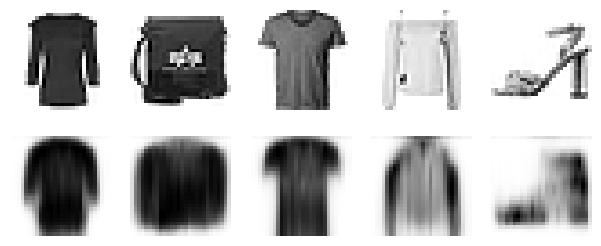

In [ ]:
show_reconstructions(recurrent_ae)
plt.show()

The reconstructions from the recurrent autoencoder show how well the LSTM layers manage to learn and reproduce the pixel sequences. This visualization helps in evaluating its effectiveness for image reconstruction.

### Stacked deoising autoencoders

### Stacked Denoising Autoencoders

Denoising autoencoders are trained to reconstruct a clean input from a corrupted version of that input. This forces the autoencoder to learn more robust features and prevents it from simply memorizing the training data. We explore two common corruption methods: adding Gaussian noise and applying dropout.

#### 1. Adding Gaussian noise

#### 1. Adding Gaussian Noise

Gaussian noise is randomly added to the input images during training. The autoencoder's task is to remove this noise and reconstruct the original, clean image.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

denoising_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.GaussianNoise(0.2),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu")
])
denoising_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[30]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])
denoising_ae = keras.models.Sequential([denoising_encoder, denoising_decoder])
denoising_ae.compile(loss="binary_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=1.0),
                     metrics=[rounded_accuracy])
history = denoising_ae.fit(X_train, X_train, epochs=10,
                           validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3477 - rounded_accuracy: 0.8788 - val_loss: 0.3211 - val_rounded_accuracy: 0.8975
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.3115 - rounded_accuracy: 0.9102 - val_loss: 0.3075 - val_rounded_accuracy: 0.9143
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3046 - rounded_accuracy: 0.9162 - val_loss: 0.3017 - val_rounded_accuracy: 0.9210
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3004 - rounded_accuracy: 0.9200 - val_loss: 0.2988 - val_rounded_accuracy: 0.9217
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2975 - rounded_accuracy: 0.9226 - val_loss: 0.2952 - val_rounded_accuracy: 0.9261
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.2952 - rounded_accuracy: 0.9246 - val_loss: 0.2936 - val_rounded_accuracy: 0.9276
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2935 - rounded_accuracy: 0.9262 - val_loss: 0.2924 - val_r

This denoising autoencoder incorporates a `GaussianNoise` layer directly into the encoder. During training, it learns to map noisy inputs to clean outputs. This is a common regularization technique for autoencoders.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


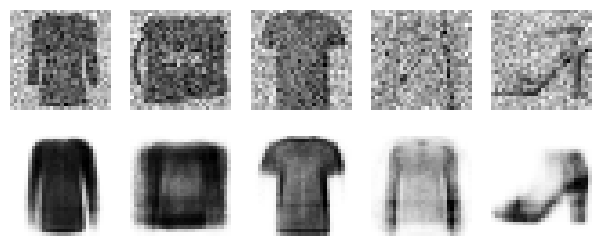

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

noise = keras.layers.GaussianNoise(0.2)
show_reconstructions(denoising_ae, noise(X_valid, training=True))
plt.show()

Here, we apply Gaussian noise to the validation images and then feed them to the denoising autoencoder. The top row shows the noisy inputs, and the bottom row shows the autoencoder's attempt to reconstruct the clean image from the noisy input. This demonstrates its denoising capability.

#### 2. Adding Dropout

#### 2. Adding Dropout

Dropout randomly sets a fraction of input units to 0 at each update during training. This form of corruption also encourages the autoencoder to learn more robust features and prevents co-adaptation of neurons.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

dropout_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu")
])
dropout_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[30]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])
dropout_ae = keras.models.Sequential([dropout_encoder, dropout_decoder])
dropout_ae.compile(loss="binary_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=1.0),
                   metrics=[rounded_accuracy])
history = dropout_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3529 - rounded_accuracy: 0.8740 - val_loss: 0.3192 - val_rounded_accuracy: 0.9056
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3176 - rounded_accuracy: 0.9035 - val_loss: 0.3111 - val_rounded_accuracy: 0.9119
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3115 - rounded_accuracy: 0.9086 - val_loss: 0.3072 - val_rounded_accuracy: 0.9152
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3077 - rounded_accuracy: 0.9118 - val_loss: 0.3039 - val_rounded_accuracy: 0.9185
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3052 - rounded_accuracy: 0.9137 - val_loss: 0.3017 - val_rounded_accuracy: 0.9209
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3034 - rounded_accuracy: 0.9153 - val_loss: 0.3006 - val_rounded_accuracy: 0.9221
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3018 - rounded_accuracy: 0.9165 - val_loss: 0.2983 - val_rou

This denoising autoencoder uses a `Dropout` layer in the encoder to corrupt the input. The model must learn to reconstruct the full image despite missing some input information due to dropout.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


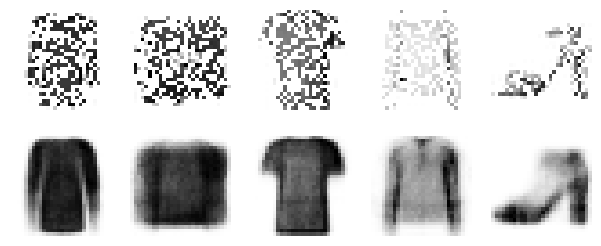

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

dropout = keras.layers.Dropout(0.5)
show_reconstructions(dropout_ae, dropout(X_valid, training=True))

We apply dropout to the validation images before feeding them to the denoising autoencoder. The visualization shows the corrupted inputs (top row) and the corresponding reconstructed images (bottom row), demonstrating the model's ability to fill in missing information.

###sparse autoencoder using KL Divergence

### Sparse Autoencoders using KL Divergence

Sparse autoencoders aim to enforce sparsity in the latent representation. This means that only a small number of neurons in the hidden layer are active at any given time. Sparsity can lead to more disentangled and interpretable features. We achieve this by adding a KL Divergence regularization term to the loss function.

In [ ]:
K = keras.backend
kl_divergence = keras.losses.kullback_leibler_divergence

class KLDivergenceRegularizer(keras.regularizers.Regularizer):
    def __init__(self, weight, target=0.1):
        self.weight = weight
        self.target = target
    def __call__(self, inputs):
        mean_activities = K.mean(inputs, axis=0)
        return self.weight * (
            kl_divergence(self.target, mean_activities) +
            kl_divergence(1. - self.target, 1. - mean_activities))

The `KLDivergenceRegularizer` class implements a custom regularizer that penalizes deviations from a target mean activation for the hidden layer neurons. This encourages sparsity in the latent space.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

kld_reg = KLDivergenceRegularizer(weight=0.05, target=0.1)
sparse_kl_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(300, activation="sigmoid", activity_regularizer=kld_reg)
])
sparse_kl_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[300]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])
sparse_kl_ae = keras.models.Sequential([sparse_kl_encoder, sparse_kl_decoder])
sparse_kl_ae.compile(loss="binary_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=1.0),
              metrics=[rounded_accuracy])
history = sparse_kl_ae.fit(X_train, X_train, epochs=10,
                           validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.5983 - rounded_accuracy: 0.7729 - val_loss: 0.5322 - val_rounded_accuracy: 0.7812
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4205 - rounded_accuracy: 0.8347 - val_loss: 0.4664 - val_rounded_accuracy: 0.8034
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3995 - rounded_accuracy: 0.8555 - val_loss: 0.4486 - val_rounded_accuracy: 0.8125
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3815 - rounded_accuracy: 0.8723 - val_loss: 0.4333 - val_rounded_accuracy: 0.8170
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3699 - rounded_accuracy: 0.8805 - val_loss: 0.4247 - val_rounded_accuracy: 0.8224
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3604 - rounded_accuracy: 0.8886 - val_loss: 0.4148 - val_rounded_accuracy: 0.8307
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3514 - rounded_accuracy: 0.8941 - val_loss: 0.4041 - val_ro

This sparse autoencoder includes the `KLDivergenceRegularizer` on the activity of the dense layer in the encoder. The target sparsity is set to 0.1, meaning we want approximately 10% of the neurons to be active on average.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


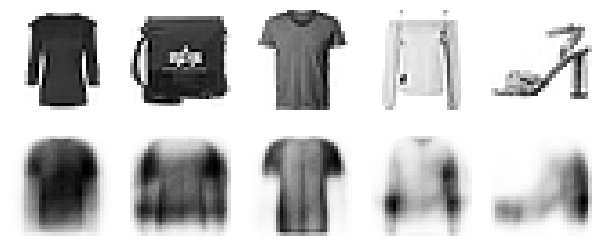

In [ ]:
show_reconstructions(sparse_kl_ae)

Visualizing the reconstructions from the sparse autoencoder helps in understanding the impact of sparsity on the quality of the reconstructed images. While encouraging sparsity, we still expect reasonable reconstruction quality.

In [ ]:
def plot_percent_hist(ax, data, bins):
    counts, _ = np.histogram(data, bins=bins)
    widths = bins[1:] - bins[:-1]
    x = bins[:-1] + widths / 2
    ax.bar(x, counts / len(data), width=widths*0.8)
    ax.xaxis.set_ticks(bins)
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
        lambda y, position: "{}%".format(int(np.round(100 * y)))))
    ax.grid(True)

### Activation Histograms for Sparse Autoencoder

To verify the effectiveness of the sparsity regularization, we can plot histograms of the neuron activations and their mean activities in the latent layer. This should show that most activations are close to zero, and the average activation across neurons is close to the target sparsity.

In [ ]:
def plot_activations_histogram(encoder, height=1, n_bins=10):
    X_valid_codings = encoder(X_valid).numpy()
    activation_means = X_valid_codings.mean(axis=0)
    mean = activation_means.mean()
    bins = np.linspace(0, 1, n_bins + 1)

    fig, [ax1, ax2] = plt.subplots(figsize=(10, 3), nrows=1, ncols=2, sharey=True)
    plot_percent_hist(ax1, X_valid_codings.ravel(), bins)
    ax1.plot([mean, mean], [0, height], "k--", label="Overall Mean = {:.2f}".format(mean))
    ax1.legend(loc="upper center", fontsize=14)
    ax1.set_xlabel("Activation")
    ax1.set_ylabel("% Activations")
    ax1.axis([0, 1, 0, height])
    plot_percent_hist(ax2, activation_means, bins)
    ax2.plot([mean, mean], [0, height], "k--")
    ax2.set_xlabel("Neuron Mean Activation")
    ax2.set_ylabel("% Neurons")
    ax2.axis([0, 1, 0, height])

The `plot_activations_histogram` function generates two histograms: one for the distribution of all activations in the latent layer across the validation set, and another for the distribution of the mean activation for each neuron in the latent layer. This helps visualize if the target sparsity is being met.

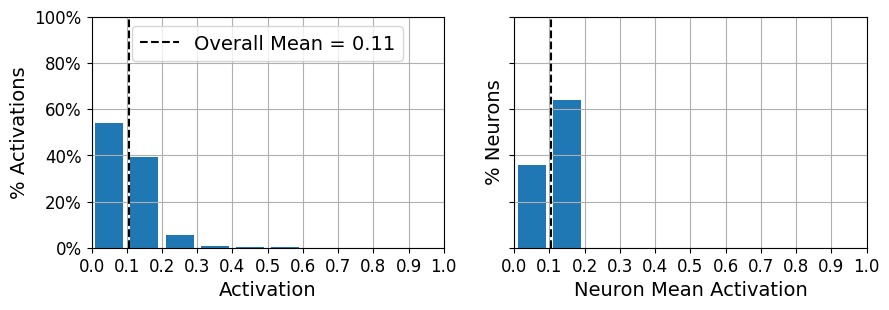

In [ ]:
plot_activations_histogram(sparse_kl_encoder)
plt.show()

These histograms illustrate the effect of KL Divergence regularization. The 'Activation' histogram on the left shows that a large percentage of activations are near zero, confirming sparsity. The 'Neuron Mean Activation' histogram on the right indicates that the average activation across neurons is close to our target of 0.11 (indicated by the dashed line), suggesting successful sparsity enforcement.

## Summary and Comparison of Autoencoder Models

This notebook explored various autoencoder architectures on the Fashion MNIST dataset, each with distinct advantages and use cases:

1.  **Stacked Autoencoder:**
    *   **Architecture:** Multiple dense layers, trained end-to-end.
    *   **Performance:** Generally good reconstruction quality for basic feature learning. Latent space visualization with t-SNE showed some clustering of similar classes.
    *   **Best For:** Simple dimensionality reduction and initial feature learning tasks.

2.  **Autoencoder Trained One-at-a-Time (Greedy Layer-wise Training):**
    *   **Architecture:** Individual autoencoder layers trained sequentially, then stacked.
    *   **Performance:** Achieved comparable or slightly better reconstruction quality than the end-to-end trained stacked autoencoder, as pre-training can help initialize weights more effectively.
    *   **Best For:** Deep autoencoders where end-to-end training might be challenging or prone to local minima.

3.  **Convolutional Autoencoder:**
    *   **Architecture:** Uses convolutional layers for encoding and `Conv2DTranspose` (deconvolutional) layers for decoding, preserving spatial information.
    *   **Performance:** Produced visually sharper and more detailed reconstructions, leveraging convolutional networks' strength in image tasks.
    *   **Best For:** Image data, where spatial hierarchies and local patterns are crucial.

4.  **Recurrent Autoencoder:**
    *   **Architecture:** Employs LSTM layers to process images as sequences (e.g., row by row).
    *   **Performance:** Showed reasonable reconstruction, demonstrating the capability of LSTMs to capture dependencies across pixels when treated as sequences. Reconstructions were generally less sharp than convolutional models for images.
    *   **Best For:** Data with inherent sequential characteristics or when exploring sequential processing of non-sequential data.

5.  **Denoising Autoencoders:**
    *   **Architecture:** Trained to reconstruct clean input from corrupted versions (Gaussian noise or Dropout).
    *   **Performance:**
        *   **Gaussian Noise:** Effectively removed noise and reconstructed clean images, learning robust features.
        *   **Dropout:** Successfully filled in missing information from dropout-corrupted inputs, indicating robustness.
    *   **Best For:** Learning more robust features, data imputation, and pre-training for supervised tasks where inputs might be noisy or incomplete.

6.  **Sparse Autoencoder (with KL Divergence Regularization):**
    *   **Architecture:** Enforces sparsity in the latent space by penalizing deviations from a target mean activation using KL Divergence regularization.
    *   **Performance:** Showed successful sparsity enforcement, with most latent unit activations close to zero. Reconstructions were generally good, demonstrating that sparsity can lead to meaningful feature extraction without significantly compromising reconstruction quality.
    *   **Best For:** Learning disentangled and interpretable features, especially when seeking a compact and efficient representation where only a few features are active at a time.